## EKF + SGD learning of Poisson LDS using simulated data

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from jax import vmap, value_and_grad, jit
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import (
    ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals,
    conditional_moments_gaussian_smoother as cmgs,
)
from dynamax.utils.utils import random_rotation

# Simulate data
state_dim, observations_dim, num_timesteps, num_trials = 2, 10, 100, 2

key = jr.key(0)
dynamics_matrix = random_rotation(key, state_dim, theta=jnp.pi / 20)
C_true = jr.normal(key, shape=(observations_dim, state_dim))
d_true = 3.0

In [2]:
# Make true params into dynamax format
def make_params(C, d):
    return ParamsGGSSM(
        initial_mean=jnp.zeros(state_dim),
        initial_covariance=jnp.eye(state_dim),
        dynamics_function=lambda z: dynamics_matrix @ z,
        dynamics_covariance=0.001 * jnp.eye(state_dim),
        emission_mean_function=lambda z: softplus(C @ z + d), # Emissions are observations
        emission_cov_function=lambda z: jnp.diag(softplus(C @ z + d)),
        emission_dist=lambda mu, Sigma: Poisson(rate=softplus(mu)),
    )

# True params gives us a sense of the error induced by CMGF approximations
model = GeneralizedGaussianSSM(state_dim, observations_dim)
true_params = make_params(C_true, d_true)

In [3]:
# sample
all_states, all_observations = vmap(
    lambda key: model.sample(true_params, key, num_timesteps=num_timesteps)
)(jr.split(jr.key(0), num_trials))

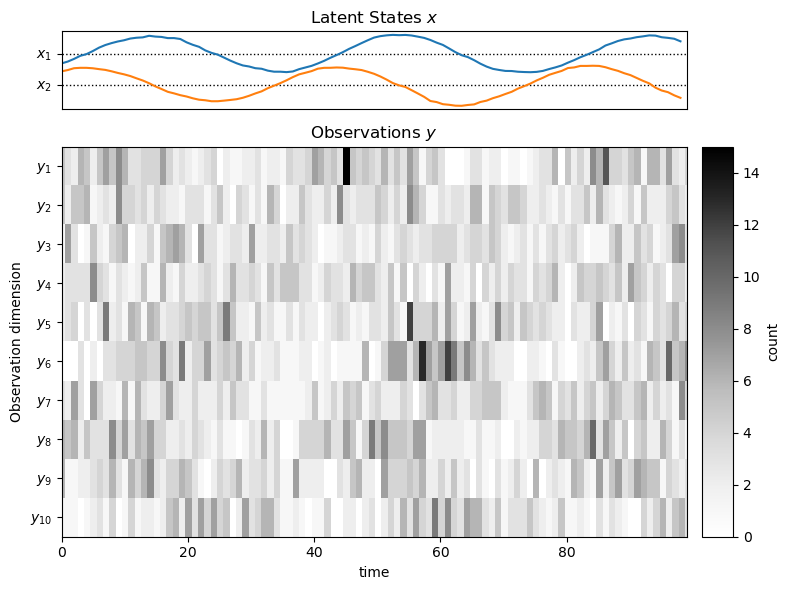

In [16]:
def plot_emissions_poisson(states, data):
    """
    Plot the emissions of a Poisson :DS
    """
    latent_dim = states.shape[-1]
    emissions_dim = data.shape[-1]
    num_timesteps = data.shape[0]

    fig, axs = plt.subplots(2, 2, 
                            height_ratios=(1, emissions_dim / latent_dim), 
                            width_ratios=(20,1), figsize=(8, 6))
    
    # Plot the continuous latent states
    lim = 1.5 * abs(states).max()
    for d in range(latent_dim):
        axs[0,0].axhline(-lim * d, color='k', ls=':', lw=1)
        axs[0,0].plot(states[:, d] - lim * d, "-")
    axs[0,0].set_yticks(-jnp.arange(latent_dim) * lim)
    axs[0,0].set_yticklabels(["$x_{}$".format(d + 1) for d in range(latent_dim)])
    axs[0,0].set_xticks([])
    axs[0,0].set_xlim(0, num_timesteps)
    axs[0,0].set_title(r"Latent States $x$")

    axs[0,1].set_visible(False)

    lim = abs(data).max()
    im = axs[1,0].imshow(data.T, aspect="auto", interpolation="none", cmap="Greys")
    axs[1,0].set_xlabel("time")
    axs[1,0].set_xlim(0, num_timesteps - 1)
    axs[1,0].set_yticks(jnp.arange(emissions_dim))
    axs[1,0].set_yticklabels([rf"$y_{{ {i+1}}}$" for i in jnp.arange(emissions_dim)])
    axs[1,0].set_ylabel("Observation dimension")
    axs[1,0].set_title(r"Observations $y$")
    plt.colorbar(im, cax=axs[1,1], label="count")

    plt.tight_layout()
    
plot_emissions_poisson(all_states[0], all_observations[0])

In [4]:
# Inference part 
# SGD
def loss_fn(theta, observations):
    """
    Compute the negative log-likelihood using EKF like integrals. This is the Conditional Marginal Gaussian Smoother (CMGS) objective, which is an approximation to the true marginal log-likelihood. (E step of EM)
    
    Returns:
        Negative log-likelihood
    """
    C, log_d = theta
    params = make_params(C, jnp.exp(log_d))
    posts = vmap(lambda e: cmgs(params, EKFIntegrals(), e))(observations) # approximated posterior over states given observations
    return -jnp.sum(posts.marginal_loglik)

key = jr.key(42)
# Initialize C and d
# C: small random values shape is n_observed x n_latents, this is the loading matrix of how the latents affect the observation
# d: is mean firing rate like 1.0 (log) (low firing rate)
# C_init = C_true + 0.5 * jr.normal(key, shape=(observations_dim, state_dim))
mean_rate = jnp.mean(all_observations)  # mean spike count per bin
# log_d_init = jnp.log(jnp.mean(all_observations))

C_init = 0.5 * jr.normal(key, shape=(observations_dim, state_dim))
log_d_init = jnp.log(2)

theta = (C_init, log_d_init)

optimizer = optax.adam(5e-3)
opt_state = optimizer.init(theta)

@jit
def step(theta, opt_state, observations):
    """
    Perform optimization step using the CMGS negative log-likelihood as the loss function.
    (Equivalent to M step of EM, but using SGD).
    Note: This is equivalent to fit_sgd for LinearGaussianSSM, but fit_sgd is not defined for GeneralizedGaussianSSM
    
    Returns:
        Updated parameters
        New optimizer state
        Current loss
    """
    loss, grads = value_and_grad(loss_fn)(theta, observations)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(theta, updates), new_opt_state, loss

losses = []
n_epochs = 500
for epoch in range(n_epochs):
    theta, opt_state, loss = step(theta, opt_state, all_observations)
    losses.append(float(loss))
    if epoch % 25 == 0:
        print(f"epoch {epoch:4d}  neg-loglik = {loss:.2f}")

C_fit, log_d_fit = theta

epoch    0  neg-loglik = 4459.35
epoch   25  neg-loglik = 4286.71
epoch   50  neg-loglik = 4141.38
epoch   75  neg-loglik = 4037.51
epoch  100  neg-loglik = 3971.11
epoch  125  neg-loglik = 3936.54
epoch  150  neg-loglik = 3920.89
epoch  175  neg-loglik = 3912.71
epoch  200  neg-loglik = 3908.23
epoch  225  neg-loglik = 3905.87
epoch  250  neg-loglik = 3904.61
epoch  275  neg-loglik = 3903.89
epoch  300  neg-loglik = 3903.42
epoch  325  neg-loglik = 3903.08
epoch  350  neg-loglik = 3902.79
epoch  375  neg-loglik = 3902.53
epoch  400  neg-loglik = 3902.30
epoch  425  neg-loglik = 3902.09
epoch  450  neg-loglik = 3901.89
epoch  475  neg-loglik = 3901.71


In [5]:
# Get latent trajectories
key = jr.key(42)
params_init = make_params(C_init, log_d_init)
params_fit  = make_params(C_fit, jnp.exp(log_d_fit))

# True params gives us a sense of the error induced by CMGF approximations
posts_true = vmap(lambda e: cmgs(true_params,  EKFIntegrals(), e))(all_observations)
posts_init = vmap(lambda e: cmgs(params_init,  EKFIntegrals(), e))(all_observations)
posts_fit  = vmap(lambda e: cmgs(params_fit,   EKFIntegrals(), e))(all_observations)

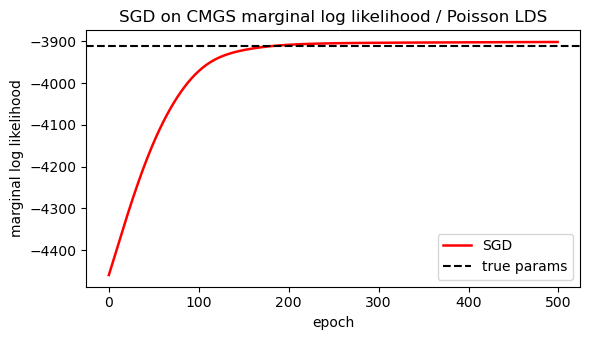

In [6]:
# Plot loss curve
true_loss = float(loss_fn((C_true, jnp.log(d_true)), all_observations))
plt.figure(figsize=(6, 3.5))
plt.plot(-jnp.array(losses), color="r", lw=1.8, label="SGD")
plt.axhline(-true_loss, color="k", ls="--", lw=1.5, label="true params")
plt.xlabel("epoch"); plt.ylabel("marginal log likelihood")
plt.title("SGD on CMGS marginal log likelihood / Poisson LDS")
plt.legend(); plt.tight_layout()

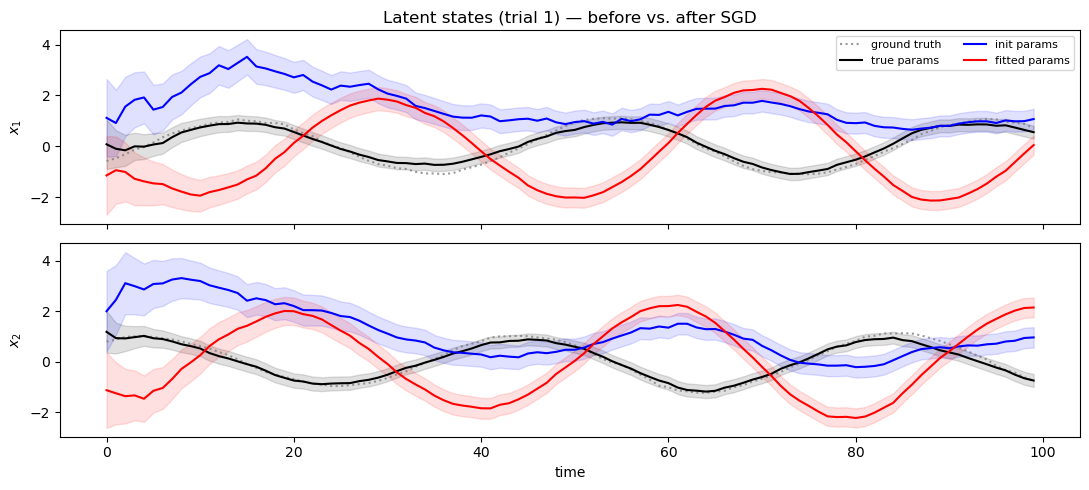

In [7]:
# plot 2
t = jnp.arange(num_timesteps)
i = 0
colors = {"true": "k", "init": "b", "fit": "r"}
labels = {"true": "true params", "init": "init params", "fit": "fitted params"}

fig, axs = plt.subplots(state_dim, 1, figsize=(11, 5), sharex=True)
for d in range(state_dim):
    axs[d].plot(all_states[i, :, d], color="gray", lw=1.5, ls=":", label="ground truth", alpha=0.8)
    for tag, posts in [("true", posts_true), ("init", posts_init), ("fit", posts_fit)]:
        mu  = posts.filtered_means[i, :, d]
        std = jnp.sqrt(posts.filtered_covariances[i, :, d, d])
        axs[d].plot(t, mu, color=colors[tag], lw=1.5, label=labels[tag])
        axs[d].fill_between(t, mu - 2*std, mu + 2*std, color=colors[tag], alpha=0.12)
    axs[d].set_ylabel(rf"$x_{d+1}$")
axs[0].set_title(f"Latent states (trial {i+1}) — before vs. after SGD")
axs[0].legend(fontsize=8, ncol=2); axs[-1].set_xlabel("time")
plt.tight_layout();

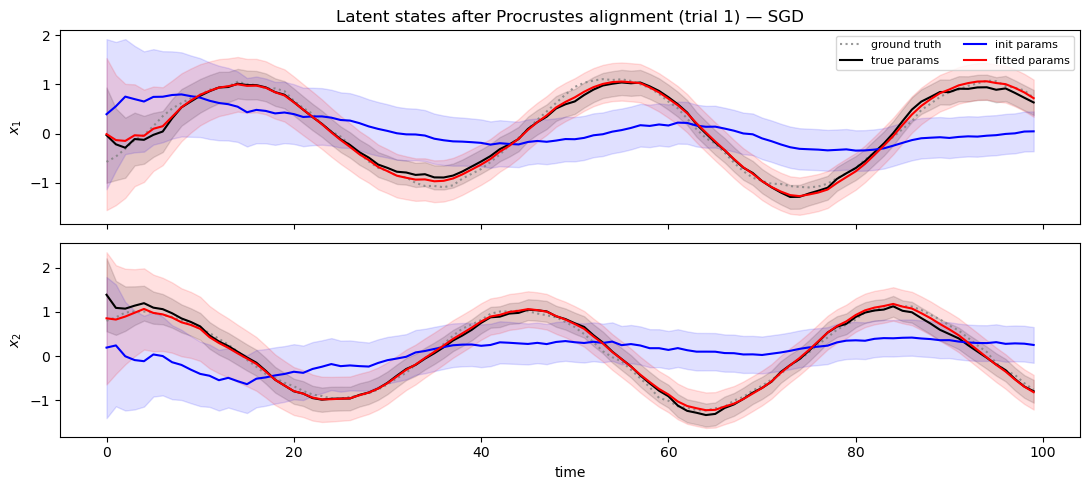

In [8]:
# Plot 2: latent trajectories, trial 0
t = jnp.arange(all_observations.shape[1])
i = 0
colors = {"true": "k", "init": "b", "fit": "r"}
labels = {"true": "true params", "init": "init params", "fit": "fitted params"}

from scipy.linalg import orthogonal_procrustes

def align_trajectories(ref, target):
    # Center
    ref_mean = ref.mean(axis=0)
    target_mean = target.mean(axis=0)
    ref_c = ref - ref_mean
    target_c = target - target_mean

    # Optimal rotation
    R, _ = orthogonal_procrustes(target_c, ref_c)

    # Optimal scale: s = tr(ref_c.T @ target_c @ R) / tr(target_c.T @ target_c)
    s = jnp.trace(ref_c.T @ (target_c @ R)) / jnp.trace(target_c.T @ target_c)

    # Apply
    return s * (target_c @ R) + ref_mean


true_states_i = all_states[i]  # (T, state_dim)

# Align fitted and init posteriors to ground truth
fitted_means_aligned = align_trajectories(true_states_i, posts_fit.filtered_means[i])
init_means_aligned = align_trajectories(true_states_i, posts_init.filtered_means[i])
true_means_aligned = align_trajectories(true_states_i, posts_true.filtered_means[i])
    
fig, axs = plt.subplots(state_dim, 1, figsize=(11, 5), sharex=True)
for d in range(state_dim):
    # Ground truth
    axs[d].plot(all_states[i, :, d], color="gray", lw=1.5, ls=":", label="ground truth", alpha=0.8)
    
    aligned = {"true": true_means_aligned, "init": init_means_aligned, "fit": fitted_means_aligned}
    # Plot each set of trajectories
    for tag, posts in [("true", posts_true), ("init", posts_init), ("fit", posts_fit)]:
        mu  = aligned[tag][:, d]  # use aligned, not posts.filtered_means
        std = jnp.sqrt(posts.filtered_covariances[i, :, d, d])
        axs[d].plot(t, mu, color=colors[tag], lw=1.5, label=labels[tag])
        axs[d].fill_between(t, mu - 2*std, mu + 2*std, color=colors[tag], alpha=0.12)
    axs[d].set_ylabel(rf"$x_{d+1}$");
axs[0].set_title(f"Latent states after Procrustes alignment (trial {i+1}) — SGD")
axs[0].legend(fontsize=8, ncol=2, loc="upper right")
axs[-1].set_xlabel("time")
plt.tight_layout()

In [9]:
def plot_observations_poisson(states, data, posts_true, posts_init, posts_fit, trial=0, use_procrustes=True):
    latent_dim = states.shape[-1]
    observations_dim = data.shape[-1]
    num_timesteps = data.shape[0]
    t = jnp.arange(num_timesteps)

    colors = {"true": "k", "init": "b", "fit": "r"}
    labels = {"true": "true params", "init": "init params", "fit": "fitted params"}
    post_map = {"true": posts_true, "init": posts_init, "fit": posts_fit}

    def align_trajectories(ref, target):
        ref_mean = ref.mean(axis=0)
        target_mean = target.mean(axis=0)
        ref_c = ref - ref_mean
        target_c = target - target_mean
        R, _ = orthogonal_procrustes(target_c, ref_c)
        s = jnp.trace(ref_c.T @ (target_c @ R)) / jnp.trace(target_c.T @ target_c)
        return s * (target_c @ R) + ref_mean

    if use_procrustes:
        means = {tag: align_trajectories(states, post_map[tag].filtered_means[trial]) for tag in ("true", "init", "fit")}
        latent_title = "Latent States $x$ (Procrustes aligned)"
    else:
        means = {tag: post_map[tag].filtered_means[trial] for tag in ("true", "init", "fit")}
        latent_title = "Latent States $x$"

    fig, axs = plt.subplots(latent_dim + 1, 2,
                            height_ratios=[1] * latent_dim + [observations_dim / latent_dim],
                            width_ratios=(20, 1), figsize=(10, 4 + latent_dim * 2))

    for d in range(latent_dim):
        ax = axs[d, 0]
        ax.plot(states[:, d], color="gray", lw=1.5, ls=":", label="ground truth", alpha=0.8)
        for tag in ("true", "init", "fit"):
            mu  = means[tag][:, d]
            std = jnp.sqrt(post_map[tag].filtered_covariances[trial, :, d, d])
            ax.plot(t, mu, color=colors[tag], lw=1.5, label=labels[tag])
            ax.fill_between(t, mu - 2*std, mu + 2*std, color=colors[tag], alpha=0.12)
        ax.set_ylabel(rf"$x_{d+1}$")
        ax.set_xticks([])
        ax.set_xlim(0, num_timesteps)
        ax.grid(True, alpha=0.2)
        if d == 0:
            ax.set_title(latent_title)
            ax.legend(fontsize=7, ncol=2, loc="upper right")
        axs[d, 1].set_visible(False)

    im = axs[latent_dim, 0].imshow(data.T, aspect="auto", interpolation="none", cmap="Greys")
    axs[latent_dim, 0].set_xlabel("time")
    axs[latent_dim, 0].set_xlim(0, num_timesteps - 1)
    axs[latent_dim, 0].set_yticks(jnp.arange(observations_dim))
    axs[latent_dim, 0].set_yticklabels([rf"$y_{{{j+1}}}$" for j in range(observations_dim)])
    axs[latent_dim, 0].set_ylabel("observation dimension")
    axs[latent_dim, 0].set_title(r"Observations $y$")
    plt.colorbar(im, cax=axs[latent_dim, 1], label="count")

    plt.suptitle(f"Trial {trial + 1}", y=1.01)
    plt.tight_layout()


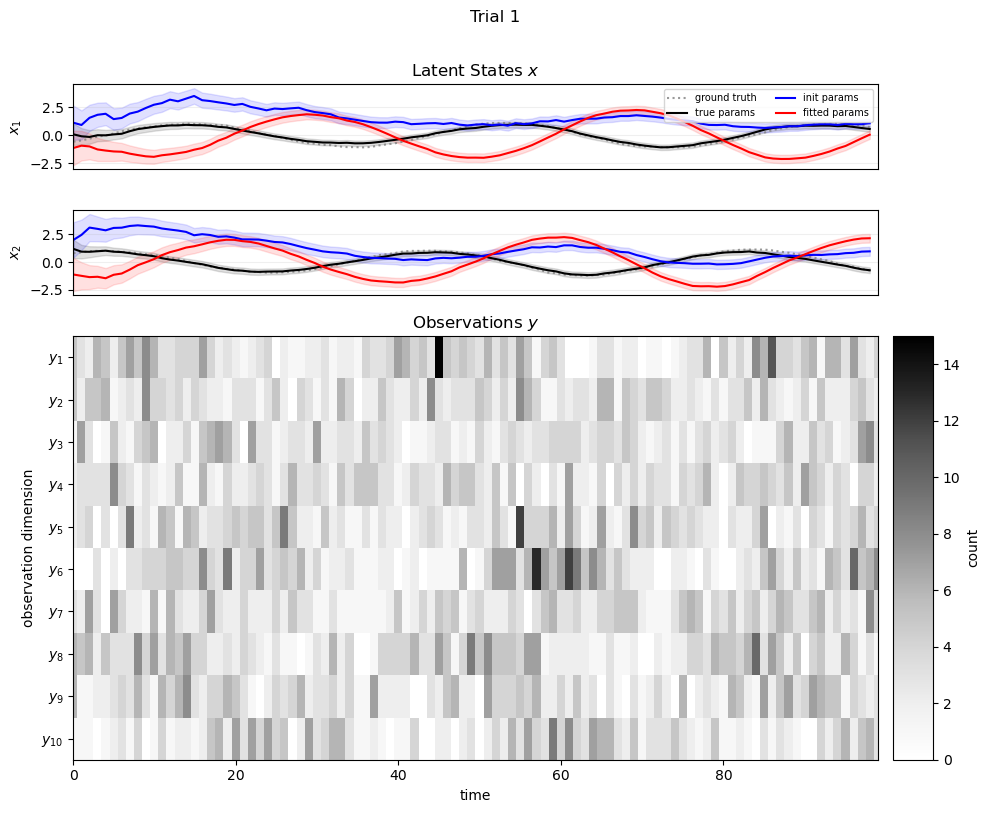

In [10]:
plot_observations_poisson(all_states[0], all_observations[0], posts_true, posts_init, posts_fit, trial=0, use_procrustes=False)

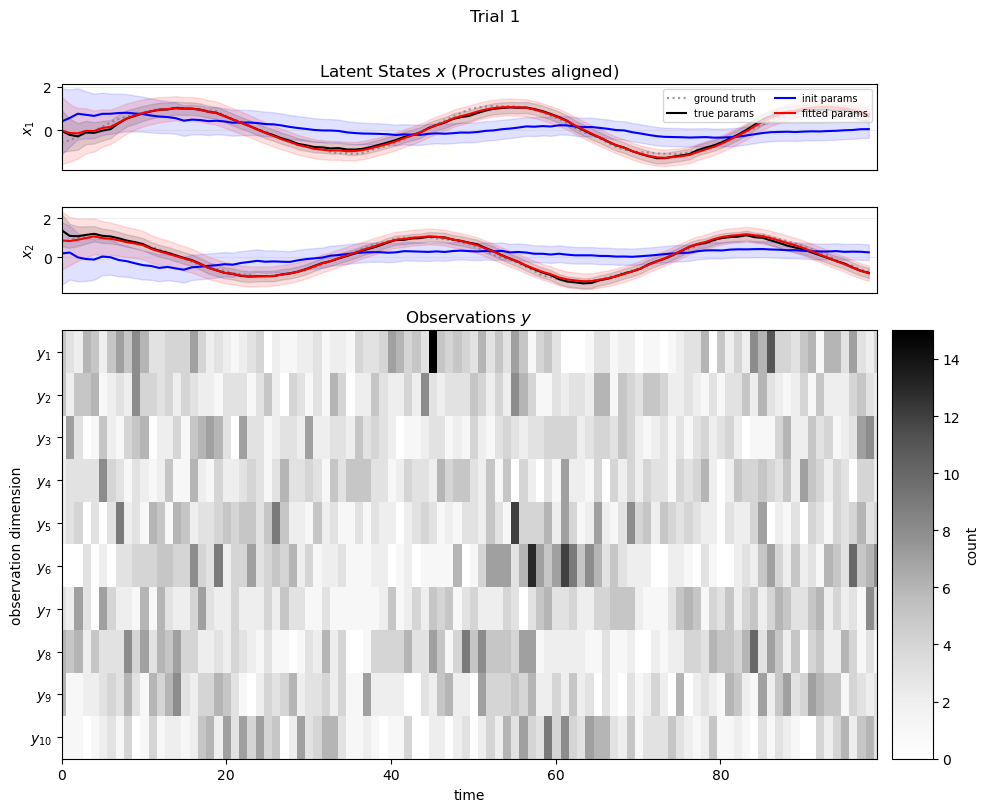

In [11]:
plot_observations_poisson(all_states[0], all_observations[0], posts_true, posts_init, posts_fit, trial=0, use_procrustes=True)